# RND - Weight Tolerance: Opportunistic Riding Benefit

Tests whether passengers who board an earlier ALTERNATIVE jeep (Group B) experience a smaller
travel-time delay than those who wait for their planned jeep (Group A), via a one-sided
Mann-Whitney U test on the delay  delta = actual - expected.

**Calibrated for speed.** Each run uses seconds_per_tick=10 and num_ticks=720 (2 h simulated),
a fixed route count, and SWEEPS weight_tolerance (the actual variable). It builds sims directly on
the pre-loaded CityGraph/DDM (no PBF rebuild) and reuses the TravelGraph across tolerance levels.
It is safe to **Run All**: the gate cell auto-calibrates the route count (escalating until enough
opportunistic riders appear at the top tolerance), so a single pass produces a valid result.

Outputs: `outputs/rnd_weight_tolerance/weight_tolerance_passengers.csv` and a delay box plot.

In [ ]:
import copy, time
from pathlib import Path
import yaml, numpy as np, pandas as pd
from scipy.stats import mannwhitneyu

from utils_simplified import reuse_citygraph, reuse_ddm, generate_route_system
from utils.travel_graph import TravelGraph
from utils.jeep import Jeep
from utils.jeep_system import JeepSystem
from utils.passenger_generator import PassengerGenerator
from utils.simulation import Simulation
from utils.passenger import Passenger, EDGE_SW, EDGE_EW, EDGE_RI

# ---------------- calibrated knobs (tune these) ----------------
NUM_ROUTES         = 10                  # enough route overlap for alternatives to exist; capped for speed
TOLERANCE_LEVELS   = [0.0, 14.44, 100.0]   # EIVM; 0 = baseline (no alternatives), 14.4 = production
REPS               = 3                   # replications per tolerance level
SECONDS_PER_TICK   = 10
NUM_TICKS          = 720                 # 2 h simulated -> enough completions for the delay test (NOT 7200)
GATING_MIN_GROUP_B = 30                  # minimum opportunistic riders for a meaningful U test

CG_PKL  = "rnd/pkl/profile_p1.pkl"
DDM_PKL = "rnd/pkl/ddm_8am.pkl"

with open("configs/profile_p1.yaml", encoding="utf-8") as f:
    base_config = yaml.safe_load(f)
base_config["simulation"]["seconds_per_tick"] = SECONDS_PER_TICK
base_config["simulation"]["num_ticks"]        = NUM_TICKS

walk_speed_kmh = float(base_config["simulation"]["passenger_speed_kmh"])
ride_speed_kmh = float(base_config["simulation"]["jeep_speed_kmh"])
spawn_rate     = base_config["simulation"].get("spawn_rate_per_hour")
print(f"routes={NUM_ROUTES} | tolerances={TOLERANCE_LEVELS} | reps={REPS}")
print(f"spt={SECONDS_PER_TICK}s | num_ticks={NUM_TICKS} ({NUM_TICKS*SECONDS_PER_TICK/3600:.1f} h sim) | spawn_rate={spawn_rate}/h")

routes=10 | tolerances=[0.0, 14.44, 100.0] | reps=3
spt=10s | num_ticks=720 (2.0 h sim) | spawn_rate=600.0/h


In [2]:
print("Loading cached CityGraph and DDM...")
t0 = time.time()
city_graph = reuse_citygraph(CG_PKL)
ddm = reuse_ddm(DDM_PKL)
print(f"Loaded in {time.time()-t0:.1f}s | {len(city_graph.nodes)} nodes, {len(city_graph.graph)} edges")

def expected_travel_minutes(journey):
    walk_m = sum(e.getLength() for e in journey if e._edge_type in (EDGE_SW, EDGE_EW))
    ride_m = sum(e.getLength() for e in journey if e._edge_type == EDGE_RI)
    return walk_m/1000.0/walk_speed_kmh*60.0 + ride_m/1000.0/ride_speed_kmh*60.0

def build_sim(tg, routes, weight_tolerance):
    # Build a Simulation directly on the pre-loaded city_graph/ddm and a prebuilt TravelGraph.
    sc = base_config["simulation"]
    jpr = max(1, int(sc.get("total_allocatable_jeeps", 470)) // len(routes))
    jeeps = []
    for route in routes:
        for _ in range(jpr):
            start = (route.path[0].start.lon, route.path[0].start.lat)
            jeeps.append(Jeep(route, curr_pos=start, speed=float(sc.get("jeep_speed_kmh", 20.0)),
                              max_capacity=int(sc.get("jeep_capacity", 16)), seconds_per_tick=SECONDS_PER_TICK))
    jeep_system = JeepSystem(jeeps=jeeps, routes=routes, weight_tolerance=float(weight_tolerance), equidistant_spawn=True)
    pg = PassengerGenerator(tg=tg, sampler=ddm, rate_per_hour=float(sc.get("spawn_rate_per_hour", 600.0)),
                            stdev=float(sc.get("spawn_stdev", 10.0)), speed=walk_speed_kmh, seconds_per_tick=SECONDS_PER_TICK)
    cfg = copy.deepcopy(base_config); cfg["disable_tqdm"] = True
    return Simulation(city_query=base_config["city_graph"]["name"], bounds=city_graph.get_bounds(),
                      jeep_system=jeep_system, passenger_generator=pg, max_ticks=NUM_TICKS,
                      beta_penalty=float(base_config.get("BETA_PENALTY", 2.0)),
                      alpha_std_penalty=float(base_config.get("ALPHA_STD_PENALTY", 0.5)), config=cfg)

def collect_rows(sim, tol):
    completed = list(sim.passenger_generator.archived_passengers)
    completed += [p for p in sim.passenger_generator.passengers if p.state == Passenger.DONE]
    rows = []
    for p in completed:
        despawn = p.despawn_tick if p.despawn_tick is not None else sim.passenger_generator.simulated_time
        exp = expected_travel_minutes(p.journey)
        act = (despawn - p.spawn_tick) / 60.0   # spawn/despawn are simulated SECONDS
        rows.append({"weight_tolerance": float(tol),
                     "took_alternative": bool(getattr(p, "took_alternative", False)),
                     "boarded_expected": bool(getattr(p, "boarded_expected", False)),
                     "expected_min": exp, "actual_min": act, "delta_min": act - exp})
    return rows

Loading cached CityGraph and DDM...
[INFO] Reusing CityGraph from pickle file: rnd/pkl/profile_p1.pkl
[INFO] Reusing DirectDemandSampler from pickle file: rnd/pkl/ddm_8am.pkl
Loaded in 2.0s | 36866 nodes, 76310 edges


In [3]:
# ---- GATE + AUTO-CALIBRATE: find a route count that yields a viable Group B, then proceed ----
# Safe for "Run All": escalates the route count until enough opportunistic riders appear (at the
# top tolerance), so the sweep below always has data. The warm (routes, tg) is reused for rep 0.
ROUTE_ESCALATION = [NUM_ROUTES, NUM_ROUTES + 6, NUM_ROUTES + 12]
chosen_routes, warm = None, None
for nr in ROUTE_ESCALATION:
    routes = generate_route_system(nr, city_graph, ddm)
    tg = TravelGraph(city_graph, config=base_config.get("travel_graph", {}), routes=routes)
    t0 = time.time()
    sim = build_sim(tg, routes, max(TOLERANCE_LEVELS)); sim.run()
    g = pd.DataFrame(collect_rows(sim, max(TOLERANCE_LEVELS)))
    n_b = int(g["took_alternative"].sum()) if len(g) else 0
    print(f"[GATE] NUM_ROUTES={nr} | completed={len(g)} | Group B={n_b} | {time.time()-t0:.0f}s")
    warm = (routes, tg)
    if n_b >= GATING_MIN_GROUP_B:
        chosen_routes = nr
        break
if chosen_routes is None:
    chosen_routes = ROUTE_ESCALATION[-1]
    print(f"[GATE][!] Group B stayed under {GATING_MIN_GROUP_B}; proceeding at NUM_ROUTES={chosen_routes} "
          f"(U test may be underpowered -- raise TOLERANCE_LEVELS top value if so).")
else:
    print(f"[GATE][OK] Using NUM_ROUTES={chosen_routes}.")

[INFO] Generating 10 routes...
[GATE] NUM_ROUTES=10 | completed=302 | Group B=10 | 124s
[INFO] Generating 16 routes...
[GATE] NUM_ROUTES=16 | completed=278 | Group B=21 | 167s
[INFO] Generating 22 routes...
[GATE] NUM_ROUTES=22 | completed=307 | Group B=23 | 190s
[GATE][!] Group B stayed under 30; proceeding at NUM_ROUTES=22 (U test may be underpowered -- raise TOLERANCE_LEVELS top value if so).


In [4]:
# ---- MAIN SWEEP: reuse the gate's warm (routes, tg) for rep 0; build fresh for later reps ----
all_rows = []
for rep in range(REPS):
    if rep == 0 and warm is not None:
        routes, tg = warm                       # reuse the calibrated gate network (no rebuild)
    else:
        routes = generate_route_system(chosen_routes, city_graph, ddm)
        tg = TravelGraph(city_graph, config=base_config.get("travel_graph", {}), routes=routes)
    for tol in TOLERANCE_LEVELS:
        t0 = time.time()
        sim = build_sim(tg, routes, tol)
        sim.run()
        rows = collect_rows(sim, tol)
        for r in rows:
            r["rep"] = rep
        all_rows.extend(rows)
        nb = sum(1 for r in rows if r["took_alternative"])
        print(f"rep={rep} tol={tol:5.1f} | completed={len(rows):4d} | Group B={nb:4d} | {time.time()-t0:.0f}s")

df = pd.DataFrame(all_rows)
out_dir = Path("outputs/rnd_weight_tolerance"); out_dir.mkdir(parents=True, exist_ok=True)
df.to_csv(out_dir / "weight_tolerance_passengers.csv", index=False)
print("")
print(f"Saved {len(df)} completed-passenger rows -> {out_dir / 'weight_tolerance_passengers.csv'}")

rep=0 tol=  0.0 | completed= 318 | Group B=   0 | 182s
rep=0 tol= 14.4 | completed= 301 | Group B=   4 | 188s
rep=0 tol=100.0 | completed= 294 | Group B=  21 | 186s
[INFO] Generating 22 routes...
rep=1 tol=  0.0 | completed= 296 | Group B=   0 | 203s
rep=1 tol= 14.4 | completed= 301 | Group B=   1 | 194s
rep=1 tol=100.0 | completed= 291 | Group B=  20 | 190s
[INFO] Generating 22 routes...
rep=2 tol=  0.0 | completed= 306 | Group B=   0 | 206s
rep=2 tol= 14.4 | completed= 324 | Group B=   1 | 192s
rep=2 tol=100.0 | completed= 331 | Group B=  16 | 193s

Saved 2762 completed-passenger rows -> outputs/rnd_weight_tolerance/weight_tolerance_passengers.csv


In [5]:
# ---- Mann-Whitney U: is Group B delay LESS than Group A delay, per tolerance level? ----
print(f"{'tol':>6} {'nA':>5} {'nB':>5} {'medA':>9} {'medB':>9} {'U':>12} {'p':>11}  verdict")
print("-" * 80)
for tol in TOLERANCE_LEVELS:
    sub = df[df["weight_tolerance"] == tol]
    a = sub.loc[sub["boarded_expected"], "delta_min"].dropna().values
    b = sub.loc[sub["took_alternative"], "delta_min"].dropna().values
    if len(a) < 1 or len(b) < 1:
        print(f"{tol:6.1f} {len(a):5d} {len(b):5d}   (insufficient samples in one group)")
        continue
    U, p = mannwhitneyu(b, a, alternative="less")   # H1: Group B delay < Group A delay
    verdict = "opportunistic riding helps (p<0.05)" if p < 0.05 else "no significant benefit"
    print(f"{tol:6.1f} {len(a):5d} {len(b):5d} {np.median(a):9.2f} {np.median(b):9.2f} {U:12.1f} {p:11.4g}  {verdict}")

   tol    nA    nB      medA      medB            U           p  verdict
--------------------------------------------------------------------------------
   0.0   890     0   (insufficient samples in one group)
  14.4   889     6      6.71      0.70        953.0    0.002205  opportunistic riding helps (p<0.05)
 100.0   829    57      6.28      4.36      20275.0     0.03648  opportunistic riding helps (p<0.05)


t=0.0: only one group present (nA=890 nB=0) - saving single-group plot
Saved plot for t=0.0 -> outputs/rnd_weight_tolerance/weight_tolerance_delta_box_t0p0.png


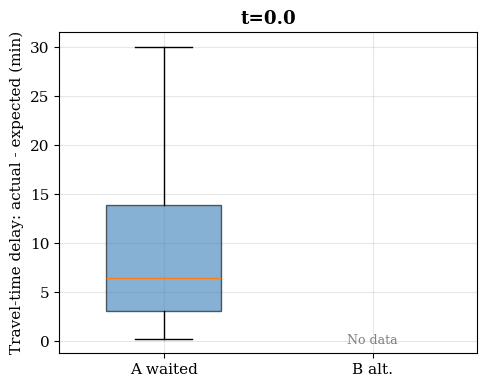

Saved plot for t=14.44 -> outputs/rnd_weight_tolerance/weight_tolerance_delta_box_t14p44.png


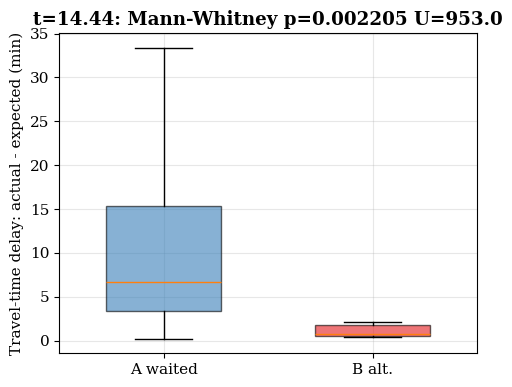

Saved plot for t=100.0 -> outputs/rnd_weight_tolerance/weight_tolerance_delta_box_t100p0.png


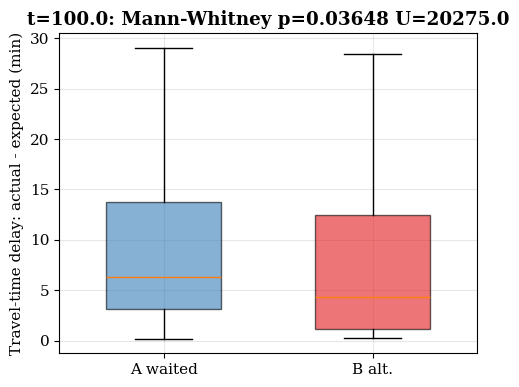

In [32]:
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.3
})

# Create one boxplot per tolerance level (A waited vs B alternative)
for tol in TOLERANCE_LEVELS:
    sub = df[df["weight_tolerance"] == tol]
    a = sub.loc[sub["boarded_expected"], "delta_min"].dropna().values
    b = sub.loc[sub["took_alternative"], "delta_min"].dropna().values

    fig, ax = plt.subplots(figsize=(5, 4))

    # Fixed positions so missing groups still leave space
    positions = []
    data = []
    colors = []

    if len(a) > 0:
        positions.append(1)
        data.append(a)
        colors.append("#377eb8")

    if len(b) > 0:
        positions.append(2)
        data.append(b)
        colors.append("#e41a1c")

    if len(a) < 1 and len(b) < 1:
        ax.text(
            0.5, 0.5, "No samples in either group",
            ha="center", va="center", fontsize=12, transform=ax.transAxes
        )
        ax.set_xticks([1, 2])
        ax.set_xticklabels(["A waited", "B alt."])
        ax.set_xlim(0.5, 2.5)
        title = f"t={tol}"
        print(f"t={tol}: no samples in either group - saving placeholder plot")

    else:
        bp = ax.boxplot(
            data,
            positions=positions,
            patch_artist=True,
            showfliers=False,
            widths=0.55
        )

        for patch, c in zip(bp["boxes"], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.6)

        # Keep both slots visible even if one group is missing
        ax.set_xticks([1, 2])
        ax.set_xticklabels(["A waited", "B alt."])
        ax.set_xlim(0.5, 2.5)

        # Optional: mark missing group
        if len(a) == 0:
            ax.text(
                1, 0.02, "No data",
                ha="center", va="bottom",
                transform=ax.get_xaxis_transform(),
                fontsize=9, color="gray"
            )
        if len(b) == 0:
            ax.text(
                2, 0.02, "No data",
                ha="center", va="bottom",
                transform=ax.get_xaxis_transform(),
                fontsize=9, color="gray"
            )

        if len(a) > 0 and len(b) > 0:
            U, p = mannwhitneyu(b, a, alternative="less")
            title = f"t={tol}: Mann-Whitney p={p:.4g} U={U:.1f}"
        else:
            title = f"t={tol}"
            print(f"t={tol}: only one group present (nA={len(a)} nB={len(b)}) - saving single-group plot")

    ax.set_ylabel("Travel-time delay: actual - expected (min)")
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()

    tol_str = str(tol).replace(".", "p")
    out_file = out_dir / f"weight_tolerance_delta_box_t{tol_str}.png"
    plt.savefig(out_file, bbox_inches="tight")
    print(f"Saved plot for t={tol} -> {out_file}")
    plt.show()